In [ ]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import torch
import src.metropolis_hastings as mh
import time

from src.time_varying_vine_copula import tv_vinecop, obs_transform_pend2, action_transform_pendulum, SlidingWindowDataset
from src.copula import conditional_vine_copula
from rl_code.modelnp import pendulum
from rl_code.lspi import LSPI

from src.qbvine import qb_conditional_vine, splitdiscrete_qb_conditional_vines

In [ ]:
n_episodes, sim_len, n_eval, n_stop_modelupdate = 10, 1000, 10, 25
true_param = np.array([9.8, 2.0, 8.0, 0.5,10.0, 0.1])
true_pendulum = pendulum(true_param)
my_lspi = LSPI(true_pendulum, sim_len, None)
old_policy = my_lspi.random_policy

st = time.time()

### calculate episodic return
all_returns, disc_returns = [], []
init_state = np.random.uniform(low=-1e-10, high=1e-10, size=2)
all_s = np.empty((0, 2))
all_s2 = np.empty((0, 2))
all_a = np.empty((0,1))
episode_ends = np.zeros(n_eval, dtype = int)
end_idx = 0
for i in range(n_eval):
    eval_s, eval_a, eval_s2, eval_r = true_pendulum.simulate_episode(first_state=init_state, policy=old_policy)
    end_idx += len(eval_r)
    episode_ends[i] = end_idx-1
    print(eval_r.T)
    all_s = np.concatenate((all_s, eval_s))
    all_s2 = np.concatenate((all_s2, eval_s2))
    all_a = np.concatenate((all_a, eval_a))
    discounts = np.array(my_lspi.gamma**np.arange(len(eval_r)))
    discounted_return = discounts.T @ np.array(eval_r)
    all_returns.append(np.sum(eval_r)), disc_returns.append(discounted_return[0])
episode_ends = episode_ends[:-1]
print(f"Episode 1 return: {np.mean(all_returns)}")
print(episode_ends)
print(len(all_a))

[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
Episode 1 return: 11.5
[  8  35  45  60  68  75  83  92 115]
125


In [ ]:
# n_episodes, sim_len, n_eval, n_stop_modelupdate = 10, 1000, 5, 25
# true_param = np.array([9.8, 2.0, 8.0, 0.5,10.0, 0.1])
# true_pendulum = pendulum(true_param)
# my_lspi = LSPI(true_pendulum, sim_len, None)
# old_policy = my_lspi.random_policy
# n_acts = 0
# while n_acts <30:
#     eval_s, eval_a, eval_s2, eval_r = true_pendulum.simulate_episode(first_state=init_state, policy=old_policy)
#     end_idx += len(eval_r)
#     n_acts = len(eval_a)
# print(eval_r.T)

# all_s = eval_s
# all_a = eval_a
# all_s2 = eval_s2

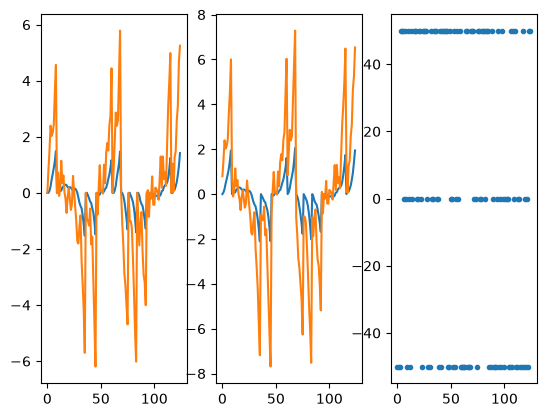

In [ ]:
fig, ax = plt.subplots(1,3)
ax[0].plot(all_s)
ax[1].plot(all_s2)
ax[2].plot(all_a, '.')


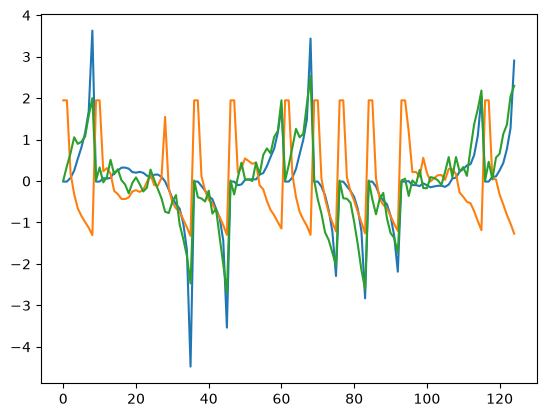

In [ ]:
data = np.concatenate((all_s, all_a), axis=1)

obs_transformer = obs_transform_pend2(standardise=True)
obs_transformer.fit(torch.from_numpy(all_s))
trans_obs = obs_transformer.transform(torch.from_numpy(all_s)).numpy()

trans_data = np.concatenate((trans_obs, all_a), axis=1)

plt.plot(trans_obs)

In [ ]:
print("Starting Fit")
# tv = tv_vinecop(observation_d=3, action_d=1, discrete_action=1, action_set=np.unique(all_a))
# tv.fit(trans_data, check_vines=True, episode_ends = None)
condcop = splitdiscrete_qb_conditional_vines(observation_d=2, discrete_action=1, action_set=np.unique(all_a))
condcop.fit(data, check_vines=True, episode_ends=episode_ends)

print("Fit finished")


Starting Fit
[3 4] [1 2] [1 2 4 5]
Cauchy Locs = [np.float64(7.403801888061707e-11), np.float64(9.638398122156151e-11)]
Scales = [np.float64(0.17848219582140912), np.float64(0.9857652269098294)]
c after hstack (125, 3)
tstemp (37, 6)
[1 2 4 5]
<pyvinecopulib.core.Vinecop> Vinecop model with 4 variables
tree edge conditioned variables conditioning variables var_types   family rotation       parameters  df  tau 
   1    1                  1, 3                             c, c    Frank        0            22.81 1.0 0.84 
   1    2                  2, 4                             c, c     Tawn      180 0.65, 1.00, 7.00 3.0 0.58 
   1    3                  3, 4                             c, c      BB7      180       4.80, 5.45 2.0 0.78 
   2    1                  1, 4                      3      c, c Gaussian        0             0.61 1.0 0.42 
   2    2                  2, 3                      4      c, c      Joe        0             1.68 1.0 0.27 
   3    1                  1, 2     

[0.999     0.8910167]


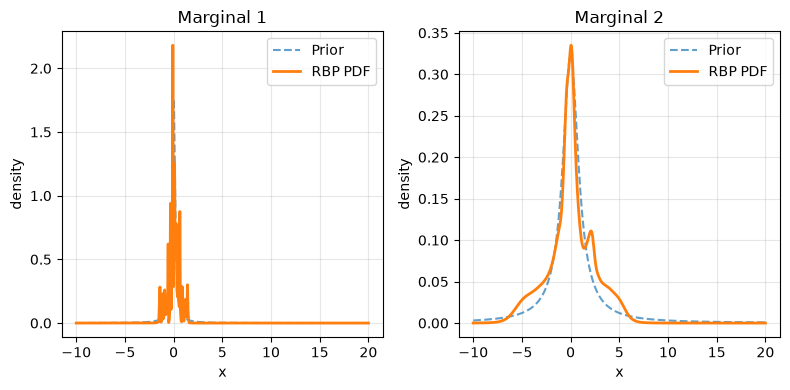

In [ ]:
condcop.check_rbp_pdfs_real_line(x_max=20)

plt.show()

In [ ]:
# condcop.step_forward(np.array([trans_obs[0]]), all_a[0][0])
# print(condcop.sample_next_state(), trans_obs[1])
condcop.step_forward(np.array([all_s[0]]), all_a[0][0])
print(condcop.sample_next_state(n_samples=20), all_s[1])

[[ 1.78315800e-08  1.03789622e+00]
 [-3.72237378e-07  1.76836448e+01]
 [-2.43209556e-06 -1.87454608e-01]
 [-3.21170721e-06  7.67030396e-01]
 [-7.42598274e-08  3.85961706e-01]
 [-3.10151545e-07  4.90735361e+00]
 [-1.05883117e-07  2.55895165e+00]
 [-2.47094292e-05  1.55112476e-01]
 [ 7.83287708e-07  2.95468501e+00]
 [-3.35654124e-07  4.29602359e+00]
 [ 2.02642501e-08  1.41499413e+00]
 [ 7.54403832e-07 -3.78168455e+01]
 [ 6.20208630e-02  4.95483823e+00]
 [ 1.14032964e-01  2.82799856e+00]
 [-6.33348929e-08  1.03551371e+00]
 [-3.13305620e-07  4.41113199e+00]
 [ 9.35300348e-06  2.03484958e+00]
 [ 1.26230558e-07  1.67047942e+00]
 [ 2.99800715e-07  3.37158740e+00]
 [ 1.17107074e-07  1.08842539e+00]] [7.01807596e-11 7.98584226e-01]


In [ ]:
predicted_next = np.zeros_like(all_s)
num_samples = 10
predicted_next[0] = all_s[0]

In [ ]:
#condcop.step_forward(np.array([trans_obs[0]]), all_a[0][0])
condcop.step_forward(np.array([all_s[0]]), all_a[0][0])
for i, act in enumerate(all_a[0:-1]):
    print(i)
    got = False
    error_count = 0
    while not got:
        try:
            preds = condcop.sample_next_state(n_samples=num_samples)
            got = True
        except:
            print("error")
            error_count +=1
            if error_count>5:
                break
            got = False

    predicted_next[i+1] = np.mean(preds, axis = 0)

    #predicted_next[i+1] = obs_transformer.inv_transform_mean(torch.from_numpy(preds))

    print(i, act[0])
    #pred = obs_transformer.transform(torch.from_numpy(np.expand_dims(predicted_next[i+1], axis = 0)))
    #print(pred)
    #print(trans_obs[i+1])
    print(predicted_next[i+1])
    print(all_s[i+1])
    condcop.step_forward(np.expand_dims(predicted_next[i+1], axis = 0), all_a[i+1][0])
    #condcop.step_forward(np.array([trans_obs[i+1]]), all_a[i+1][0])

0
0 -50.0
[-9.82166955e-05  5.29325838e+00]
[7.01807596e-11 7.98584226e-01]
1
1 -50.0
[  0.78426948 -21.75059387]
[0.07985842 1.51244887]
2
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error
error


In [ ]:
fig, ax = plt.subplots(1,2)
x = np.arange(len(predicted_next))
#Plot the 
for i in range(2):
    ax[i].plot(x, all_s2[:,i], label = "Observed")
    ax[i].plot(x, predicted_next[:,i], label = "Prediction")
    # ax[0, i].fill_between(
    #     x,
    #     predicted_up_err[:, i],
    #     predicted_down_err[:, i],
    #     color = "orange",
    #     alpha=0.25,
    #     label="Prediction uncertainty"
    # )
    #ax[1, i].plot(observations[:,i], predicted_next[:,i] - observations[:,i], '.')

#print(observations[-11], observations[-10], np.mean(chain, axis=0), observations[-9])
plt.savefig("C:/Users/woodg/Documents/Vine_dissertation_chaeyun/plots_rl/roll_out_discrete_notrans")
plt.close()

## Appendix

In [ ]:
print(trans_obs[0])

tv.step_forward(np.array([trans_obs[0]]), all_a[0][0])
print(tv.last_state.shape)
print(np.array([trans_obs[0]]))



tv.check_rbp_pdfs_real_line(x_max=30)
#tv.check_conditional_vine_pdfs()
tv.check_rbp_times_conditional_vine()
plt.show()

[0.0645077  1.61885399 0.14544268]


NameError: name 'tv' is not defined

In [ ]:
tv.step_forward(np.array([trans_obs[0]]), all_a[0][0])


for i, act in enumerate(all_a[0:9]):
    pred, pred_std, ar, fig = tv.predict_next_state(action = act[0], covariance=0.01, chain_length=600, 
                                                    burn_in = 300, check_chain=True, check_acceptance = False)
    plt.show()
    plt.close()
    print(pred)
    predicted_next[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred, axis=0)))
    predicted_up_err[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred+pred_std, axis=0)))
    predicted_down_err[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred-pred_std, axis=0)))
    print(i, act[0], ar)

    tv.step_forward(np.array([pred]), all_a[i+1][0])

In [ ]:
print(predicted_next)
fig, ax = plt.subplots(2,2)
x = np.arange(len(predicted_next))
#Plot the 
for i in range(2):
    ax[0, i].plot(x, all_s2[:,i], label = "Observed")
    ax[0, i].plot(x, predicted_next[:,i], label = "Prediction")
    ax[0, i].fill_between(
        x,
        predicted_up_err[:, i],
        predicted_down_err[:, i],
        color = "orange",
        alpha=0.25,
        label="Prediction uncertainty"
    )
    #ax[1, i].plot(observations[:,i], predicted_next[:,i] - observations[:,i], '.')

#print(observations[-11], observations[-10], np.mean(chain, axis=0), observations[-9])
plt.savefig("C:/Users/woodg/Documents/Vine_dissertation_chaeyun/plots_rl/roll_out_discrete")
plt.close()